##  Pre-processing 


This notebook shows:
- How to load a 4DSTEM dataset.
- Mask pixels
- Calibration
- Save Vacuum Probe

### Authors

This tutorial was created by the py4DSTEM instructor team:
- Colin Ophus (cophus@gmail.com)
- Ben Savitzky (bhsavitzky@lbl.gov)
- Stephanie Ribet (sribet@lbl.gov)

Last updated: 2025 May 3

In [1]:
# This painful import cell is required because of incompatbility between colab's
# version of numpy and the version required by py4DSTEM.

import numpy as np
import py4DSTEM as p4
import matplotlib.pyplot as plt
%matplotlib inline

cupyx.jit.rawkernel is experimental. The interface can change in the future.


In [2]:
import os
import sys
# List h5 files in path directory containing "master" in filename
# path = "/Volumes/Extreme SSD/Data/250801/"
path = 'D:\\Data\\250815\\'
h5_files = [f for f in os.listdir(path) if f.endswith('.h5') and 'master' in f]
print("\nH5 files containing 'master':")
for f in h5_files:
    print(f)



H5 files containing 'master':
08152025_Al-Al_91mm_30mrad_0nm_px18.61pm_00_master.h5
08152025_Al-Al_91mm_30mrad_0nm_px18.61pm_01_master.h5
08152025_Al-Al_91mm_30mrad_100nm_px13p16pm_min_00_master.h5
08152025_Al-Al_91mm_30mrad_10nm_px18.61pm_00_master.h5
08152025_Al-Al_91mm_30mrad_10nm_px18.61pm_00_master_masked.h5
08152025_Al-Al_91mm_30mrad_15nm_px13p16pm_00_master.h5
08152025_Al-Al_91mm_30mrad_15nm_px13p16pm_00_master_masked.h5
08152025_Al-Al_91mm_30mrad_15nm_px13p16pm_01_master.h5
08152025_Al-Al_91mm_30mrad_15nm_px13p16pm_01_master_masked.h5
08152025_Al-Al_91mm_30mrad_15nm_px13p16pm_01_master_masked_masked.h5
08152025_Al-Al_91mm_30mrad_15nm_px13p16pm_01_master_masked_masked_partial_loc200_w80.h5
08152025_Al-Al_91mm_30mrad_15nm_px13p16pm_01_master_masked_masked_partial_loc20_w100.h5
08152025_Al-Al_91mm_30mrad_15nm_px13p16pm_01_master_masked_partial_loc200_w80.h5
08152025_Al-Al_91mm_30mrad_15nm_px13p16pm_min_00_master.h5
08152025_Al-Al_91mm_30mrad_15nm_px13p16pm_min_00_master_masked.h5

# Load data

In [3]:
# set the path to the local copy of the dataset file
name = "08152025_probe_91mm_30mrad_11p65nm_px6p79pm_01_master"
filepath_data = path + name + ".h5"

# load the data
datacube = p4.import_file(filepath_data)

# print results
print(datacube)

Dataset is uint32 but will be converted to uint16
DataCube( A 4-dimensional array of shape (16, 16, 192, 192) called 'datacube',
          with dimensions:

              Rx = [0,1,2,...] pixels
              Ry = [0,1,2,...] pixels
              Qx = [0,1,2,...] pixels
              Qy = [0,1,2,...] pixels
)


In [4]:
# Examine the file contents
p4.print_h5_tree( filepath_data )

/
|---entry
    |---data
    |---instrument
    |   |---beam
    |   |---detector
    |       |---detectorSpecific
    |       |---geometry
    |       |   |---orientation
    |       |   |---translation
    |       |---goniometer
    |       |---module
    |       |---transformations
    |---sample
        |---beam
        |---goniometer
        |---transformations




# Examine individual and mean

In [5]:
np.max(datacube.data)

65535

In [6]:
# Mean and max diffraction pattern of the calibration and measurement datasets
dp_mean = datacube.get_dp_mean()
dp_max = datacube.get_dp_max()

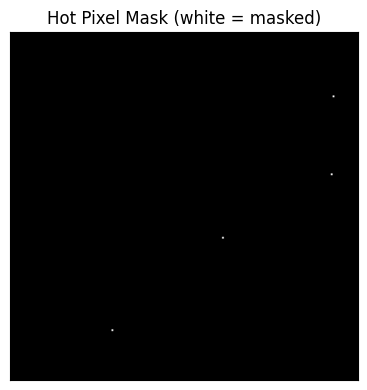

Maximum value 70


In [7]:
dataset_masked = []
for data in [datacube,]:
    mask_hotpixel = data.tree('dp_mean').data>65530
    masked = data.median_filter_masked_pixels(mask = mask_hotpixel, kernel_width = 5)
    masked.get_dp_max();
    masked.get_dp_mean();
    # Plot the hot pixel mask
    p4.show(
        mask_hotpixel,
        cmap='gray',
        figsize=(4,4),
        ticks=False,
        title='Hot Pixel Mask (white = masked)',
    )
    plt.show()
    dataset_masked.append(masked)
    print('Maximum value', np.max(masked.tree('dp_max').data))
datacube_masked = dataset_masked[0]

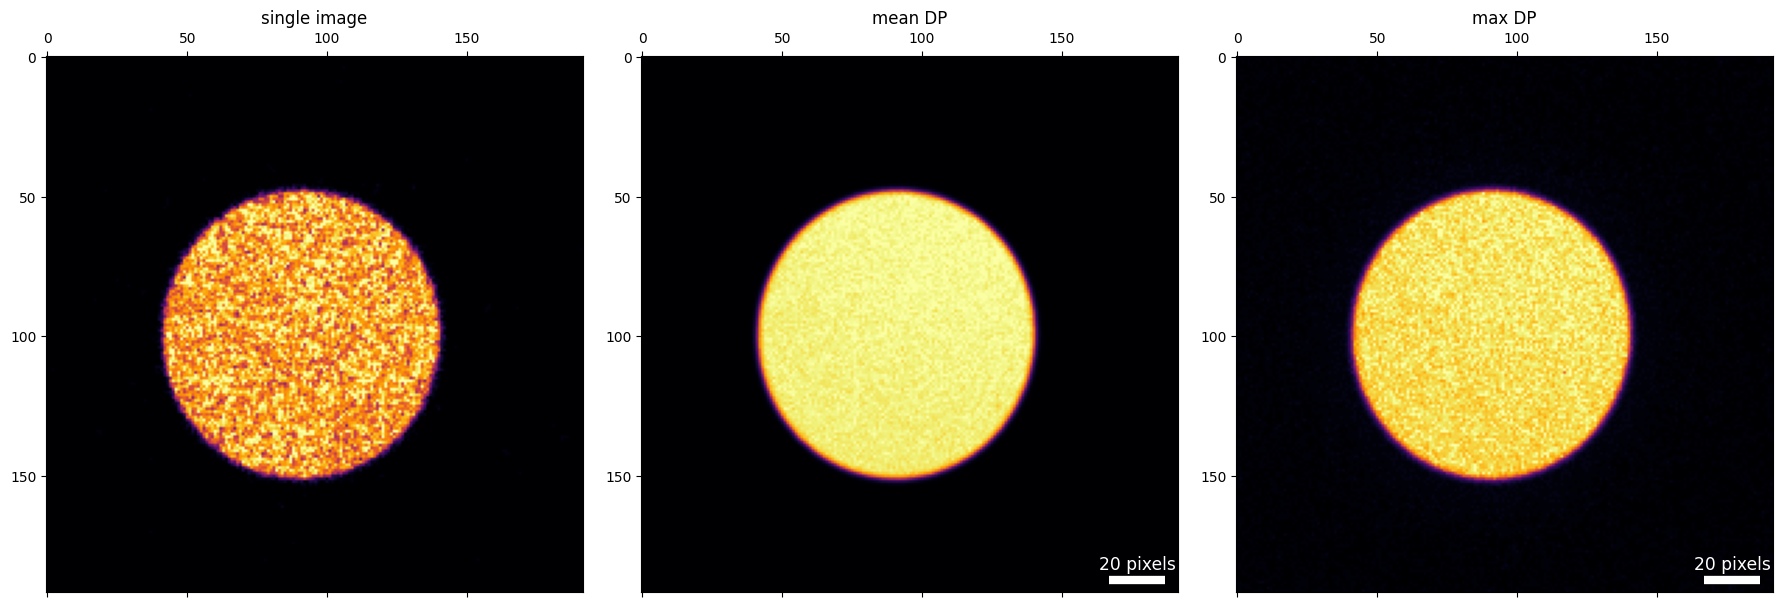

In [8]:
# show
p4.show(
    [
        datacube_masked.data[10,10],
        datacube_masked.get_dp_mean(),
        datacube_masked.get_dp_max(),
    ],
    cmap = 'inferno',
    title = ['single image','mean DP','max DP'],
    # power = 1,
)
plt.show()

Note that the center spot is shaped like a "rounded rectangle."  What you are seeing is the circular center spot, convolved with a rectangle shape corresponding to the STEM probe descan on the detector.  This is a shift of each diffraction pattern as a function of the STEM probe position. We will need to measure and correct these shifts.

In [9]:

p4.save(
    data = datacube_masked,
    filepath = path + f'{name}_masked.h5',)


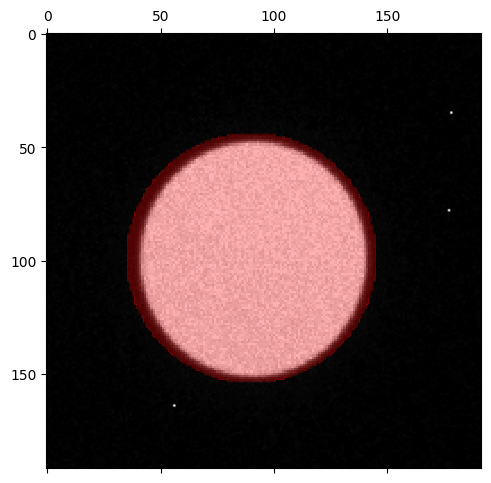

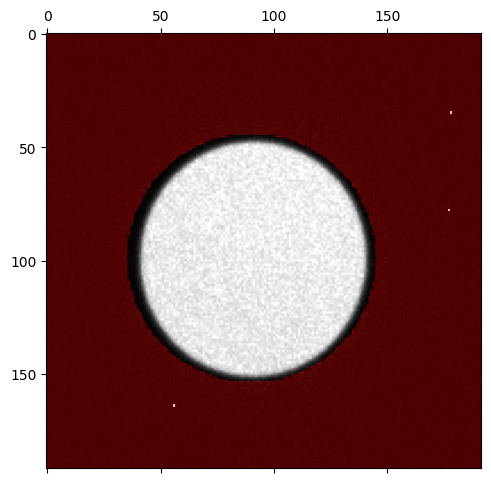

In [10]:
# Virtual imaging - position the detectors

# We'll generate a bright-field (BF) and an annular dark-field (ADF) virtual image
# for both the calibration and measurement datasets

# Set the center
center = (99,90)

# set the geometries
radius_bf = 55
geometry_bf = (center,radius_bf)
geometry_adf = (center,(radius_bf,10e3))

# display the detector positions
datacube_masked.position_detector(
    data = dp_max,
    mode = 'circle',
    geometry = geometry_bf,
)
datacube_masked.position_detector(
    data = dp_max,
    mode = 'annulus',
    geometry = geometry_adf,
)

In [11]:
# Virtual imaging - compute the images

# compute
im_bf = datacube_masked.get_virtual_image(
    mode = 'circle',
    geometry = geometry_bf,
    name = 'bright_field_cal',
)


im_adf = datacube_masked.get_virtual_image(
    mode = 'annulus',
    geometry = geometry_adf,
    name = 'dark_field_cal',
)

# show
p4.show(
    [im_bf,im_adf],
    figsize=(16,2),
    bordercolor = 'w',
    cmap='gray',
    title=['Bright Field (BF)','Annular Dark Field (ADF)'],
    axsize = (2.5,4),
)

100%|██████████| 256/256 [00:00<00:00, 11682.15it/s]


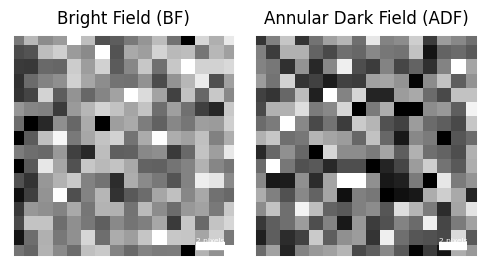

In [12]:
plt.show()

In [13]:
geometry_haddaf = (center,(radius_bf*1.5,10e3))
haddaf = datacube_masked.get_virtual_image(
    mode = 'annulus',
    geometry = geometry_haddaf,
    name = 'dark_field_cal',
)


100%|██████████| 256/256 [00:00<00:00, 13832.78it/s]


In [14]:

# show
p4.show(
    [im_bf,haddaf],
    figsize=(16,2),
    bordercolor = 'w',
    cmap='gray',
    title=['Bright Field (BF)','Annular Dark Field (ADF)'],
    axsize = (2.5,4),
)

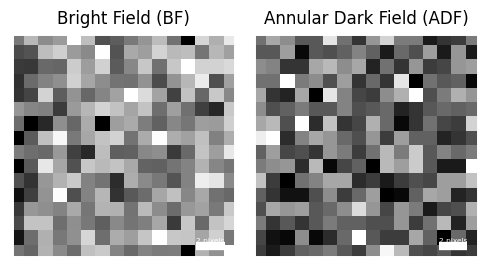

In [15]:
plt.show()

In [16]:
raise Exception("Not implemented")

Exception: Not implemented

# Construct probe template

100%|██████████| 255/255 [00:00<00:00, 291.13it/s]


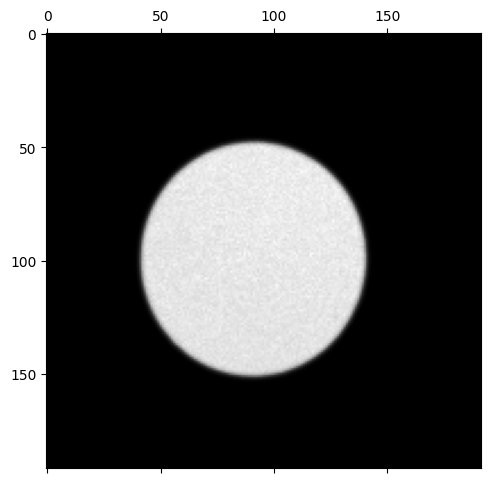

In [29]:
probe = datacube_masked.get_vacuum_probe(
    ROI = None,
)

p4.show(
    probe.probe,
    vmax=1,
)

In [30]:
probe.probe

array([[ 2.94070546e-35,  1.47035273e-35, -6.01919735e-49, ...,
        -5.58842963e-49,  2.94070546e-35,  2.94070546e-35],
       [-9.09104170e-50,  1.47035273e-35,  1.47035273e-35, ...,
        -6.75300448e-49, -9.88875439e-49,  1.47035273e-35],
       [ 3.72831688e-49, -1.02882081e-48,  1.47035273e-35, ...,
         1.47035273e-35, -1.04264990e-48, -4.33191233e-49],
       ...,
       [ 1.47035273e-35,  2.94070546e-35,  1.47035273e-35, ...,
         7.31320425e-49,  3.45674359e-50,  7.53316824e-49],
       [ 2.94070546e-35,  1.47035273e-35, -5.30362573e-49, ...,
         3.96415272e-50,  1.47035273e-35,  9.52941529e-50],
       [ 1.47035273e-35,  1.47035273e-35,  3.06059569e-49, ...,
         4.92765057e-49,  2.30441578e-50,  5.67678175e-49]])

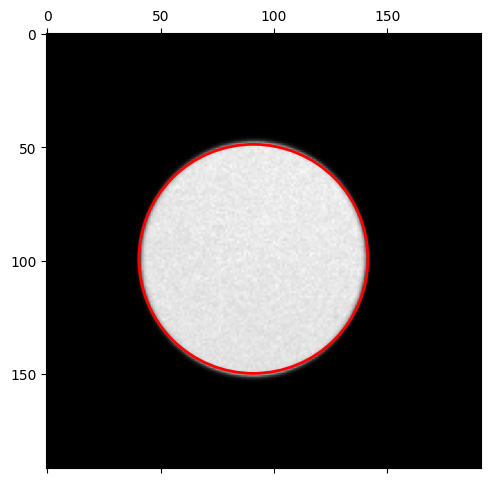

In [31]:
# Estimate the radius of the BF disk

probe_semiangle, probe_qx0, probe_qy0 = p4.process.calibration.get_probe_size(probe.probe)

p4.show(
    probe.probe,
    circle = {
        'center' : (probe_qx0,probe_qy0),
        'R' : probe_semiangle,
    },
    vmax = 1,
)

In [32]:
probe_semiangle

50.52646007988988

In [33]:
probe

Probe( A stack of 2 Arrays with 2-dimensions and shape (192, 192), called 'probe'

       The labels are:
           probe
           kernel


       The Array dimensions are:
           dim0 = [0,1,2,...] pixels
           dim1 = [0,1,2,...] pixels
)

In [39]:
probe_step_size_Ang = 30
probe_pixel_number = probe_semiangle

q_pixel_size = probe_step_size_Ang / probe_pixel_number/2
print(f"Diffraction space pixel size: {q_pixel_size} mrad")

Diffraction space pixel size: 0.29687415220228686 mrad


In [40]:
q_pixel_unit = 'mrad'
# Diffraction space
for data in [datacube_masked, probe]:
    data.calibration.set_Q_pixel_size(q_pixel_size)
    data.calibration.set_Q_pixel_units(q_pixel_unit)


In [41]:

print(datacube_masked.calibration)

Calibration( A Metadata instance called 'calibration', containing the following fields:

             Q_pixel_size:    0.29687415220228686
             R_pixel_size:    1
             Q_pixel_units:   mrad
             R_pixel_units:   pixels
             QR_flip:         False
)


In [42]:
print(probe.calibration)

Calibration( A Metadata instance called 'calibration', containing the following fields:

             Q_pixel_size:    0.29687415220228686
             R_pixel_size:    1
             Q_pixel_units:   mrad
             R_pixel_units:   pixels
             QR_flip:         False
)


100%|██████████| 255/255 [00:00<00:00, 287.32it/s]


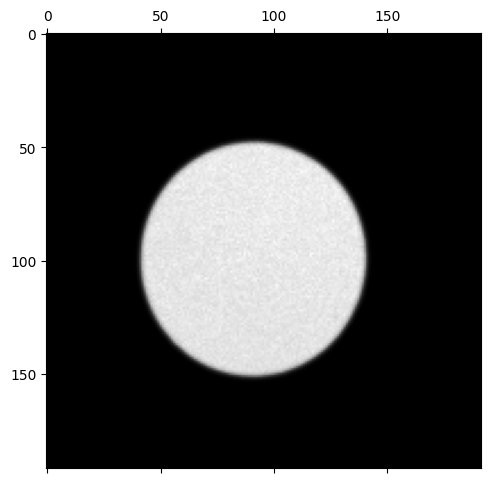

In [43]:
probe = datacube_masked.get_vacuum_probe(
    ROI = None,
)

p4.show(
    probe.probe,
    vmax=1,
)

In [44]:
raise Exception('This notebook is not yet implemented')

Exception: This notebook is not yet implemented

In [45]:
p4.save(data = probe, filepath= path + 'processed_probe_master.h5', mode = 'overwrite')


In [ ]:
path

'D:\\Data\\250815\\'

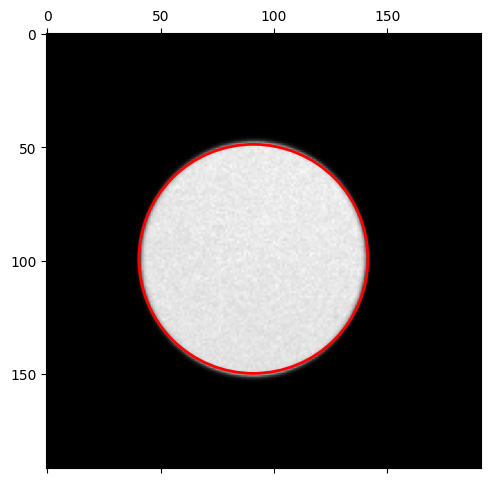

In [37]:
probe_semiangle, probe_qx0, probe_qy0 = p4.process.calibration.get_probe_size(probe.probe)

p4.show(
    probe.probe,
    circle = {
        'center' : (probe_qx0,probe_qy0),
        'R' : probe_semiangle,
    },
    vmax = 1,
)

In [38]:
probe_semiangle

50.52646007988988